# 結構方程模式 ② 衡量模型(Measurement Model)
### 三部曲之二 · 完整歷程與結果

> 承接文件①。本篇專注於 SEM 的**第一張拼圖:衡量模型**(也就是驗證性因素分析 CFA)。我們會走完一個完整的分析歷程——從模型界定,到信度、效度、適配度的評估——並輸出可直接寫進報告的結果。
>
> **核心問題**:「我的問卷題目,真的有準確測量到那些看不見的構面嗎?」

---

## 為什麼衡量模型要「先」做?(二步法)

SEM 的標準作法是 **Anderson & Gerbing (1988) 二步法**:

> **第一步(本篇)**:先單獨檢驗**衡量模型**,確認每個構面都被題目「量得準」。
> **第二步(文件③)**:題目可信了,才去檢驗**結構模型**(構面間的因果)。

道理很簡單——**Garbage in, garbage out**。如果你的「滿意度」題目根本沒量到滿意度,那後面算出「滿意度→忠誠」的影響再漂亮,也是建立在沙地上的結論。所以**測量的品質,是一切的前提**。

---
## 第 0 章　環境設定與載入案例資料

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.patches import Ellipse, FancyBboxPatch, FancyArrowPatch

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)

def use_cjk_font():
    cands = ["Noto Sans CJK TC","Noto Sans CJK SC","Noto Sans TC","Microsoft JhengHei",
             "Microsoft YaHei","PingFang TC","Heiti TC","SimHei","Arial Unicode MS","WenQuanYi Zen Hei"]
    avail = {f.name for f in fm.fontManager.ttflist}
    for n in cands:
        if n in avail:
            matplotlib.rcParams["font.family"]=n; matplotlib.rcParams["axes.unicode_minus"]=False; return n
    import glob
    for fp in glob.glob("/usr/share/fonts/**/NotoSansCJK*.ttc", recursive=True):
        try:
            fm.fontManager.addfont(fp); matplotlib.rcParams["font.family"]="Noto Sans CJK TC"
            matplotlib.rcParams["axes.unicode_minus"]=False; return "Noto Sans CJK TC"
        except Exception: pass
    matplotlib.rcParams["axes.unicode_minus"]=False; return None
print("字型:", use_cjk_font() or "(無中文字型,圖表中文可能為方框)")

字型: WenQuanYi Zen Hei


In [2]:
def _trim(p1,p2,r1,r2):
    p1=np.array(p1,float);p2=np.array(p2,float);d=p2-p1;L=np.hypot(*d)
    if L==0: return p1,p2
    u=d/L; return p1+u*r1, p2-u*r2
def node(ax,xy,text,kind="latent",w=1.6,h=1.05,fs=10):
    x,y=xy
    if kind=="latent":
        ax.add_patch(Ellipse((x,y),w,h,facecolor="#dbeafe",edgecolor="#2563eb",lw=2,zorder=3))
    else:
        ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle="round,pad=0.02",
                     facecolor="#fef3c7",edgecolor="#d97706",lw=1.8,zorder=3))
    ax.text(x,y,text,ha="center",va="center",fontsize=fs,zorder=4)
def arrow(ax,p1,p2,label=None,curved=0.0,two_head=False,r1=0.85,r2=0.85,
          color="#374151",lw=1.7,dx=0.0,dy=0.18,fs=9):
    q1,q2=_trim(p1,p2,r1,r2)
    style="<->" if two_head else "-|>"
    ax.add_patch(FancyArrowPatch(q1,q2,arrowstyle=style,mutation_scale=14,
                 connectionstyle=f"arc3,rad={curved}",color=color,lw=lw,zorder=2))
    if label:
        mx,my=(q1[0]+q2[0])/2+dx,(q1[1]+q2[1])/2+dy
        ax.text(mx,my,label,ha="center",fontsize=fs,color=color,zorder=5,
                bbox=dict(boxstyle="round,pad=0.12",fc="white",ec="none",alpha=0.9))
print("繪圖工具 node() / arrow() 已就緒")

繪圖工具 node() / arrow() 已就緒


**貫穿案例**:一份顧客問卷,3 個構面、各 3 題,共 9 題。構面為:**品質 (Quality)、滿意度 (Satisfaction)、忠誠 (Loyalty)**。

In [3]:
# === 貫穿三份文件的案例資料:品質 → 滿意度 → 忠誠(含直接路徑)===
# 真實設定:滿意度 = 0.6×品質;忠誠 = 0.3×品質(直接) + 0.5×滿意度
rng = np.random.default_rng(2024)
N = 500
Q   = rng.standard_normal(N)
Sat = 0.6*Q + np.sqrt(1-0.6**2)*rng.standard_normal(N)
varexp = 0.3**2 + 0.5**2 + 2*0.3*0.5*0.6
Loy = 0.3*Q + 0.5*Sat + np.sqrt(1-varexp)*rng.standard_normal(N)
def _ind(f, loads):
    return np.column_stack([l*f + np.sqrt(1-l**2)*rng.standard_normal(N) for l in loads])
data = pd.DataFrame(np.column_stack([
        _ind(Q,[0.82,0.78,0.74]), _ind(Sat,[0.85,0.80,0.76]), _ind(Loy,[0.83,0.79,0.72])]),
    columns=["q1","q2","q3","s1","s2","s3","l1","l2","l3"])
print("案例:300 ... 不,共", N, "位顧客;9 個問卷題目(每構面 3 題)")
print(data.head(3).round(2))

案例:300 ... 不,共 500 位顧客;9 個問卷題目(每構面 3 題)
     q1    q2    q3    s1    s2    s3    l1    l2    l3
0  0.23 -0.27  0.25 -0.58 -0.41 -0.05 -0.21  0.03  0.49
1  1.53  1.31  0.46  0.99  0.62  1.41 -0.01  1.40 -0.10
2  1.77  0.66  2.29  0.55  1.04  1.64 -0.36 -0.32 -1.25


---
## 第 1 章　衡量模型的數學

### 1-1　測量方程式

每道題目(觀察變項)= 負荷量 × 構面(潛在變項)+ 測量誤差:

$$\boxed{\;x=\Lambda\,\xi+\delta\;}$$

- $x$:題目分數向量　$\Lambda$:**因素負荷量**矩陣(每題對構面的關聯強度)
- $\xi$:看不見的構面　$\delta$:測量誤差(每題獨有的雜訊)

### 1-2　模型隱含共變異數矩陣

在 $\xi,\delta$ 不相關的假設下,題目之間的共變異數結構是:

$$\boxed{\;\Sigma=\Lambda\,\Phi\,\Lambda'+\Theta\;}$$

其中 $\Phi=\mathrm{Cov}(\xi)$(構面間相關)、$\Theta=\mathrm{Cov}(\delta)$(誤差變異,對角)。

> **衡量模型的工作**:找一組 $\Lambda,\Phi,\Theta$,讓 $\Sigma$ 盡量貼近資料的樣本共變異數矩陣 $S$。負荷量 $\Lambda$ 越大,代表題目越能反映構面。

---
## 第 2 章　完整分析歷程(六個步驟)

衡量模型的標準流程:

| 步驟 | 做什麼 | 關鍵判準 |
|---|---|---|
| **① 模型界定** | 指定哪些題量哪個構面 | 依理論/問卷設計 |
| **② 估計** | 用 ML 求 $\Lambda,\Phi,\Theta$ | 最小化 $F_{ML}$ |
| **③ 信度** | 題目一致性、構面可靠度 | 負荷量≥0.7、CR≥0.7 |
| **④ 收斂效度** | 同構面的題目是否抱團 | AVE≥0.5 |
| **⑤ 區別效度** | 不同構面是否分得開 | Fornell-Larcker、HTMT |
| **⑥ 適配度** | 整體模型貼合程度 | RMSEA、CFI、TLI、SRMR |

下面逐一說明數學,再一次跑出全部結果。

### 步驟③ 信度的數學:組合信度 CR

**組合信度 (Composite Reliability, CR)** 衡量「一個構面的所有題目,整體有多可靠地測到同一件事」。對標準化負荷量 $\lambda_i$:

$$\boxed{\;CR=\frac{\left(\sum_i\lambda_i\right)^2}{\left(\sum_i\lambda_i\right)^2+\sum_i(1-\lambda_i^2)}\;}$$

- 分子 $(\sum\lambda_i)^2$:題目共同反映構面的「真實訊號」。
- 分母多出的 $\sum(1-\lambda_i^2)=\sum\theta_i$:各題的「測量誤差」。
- **CR ≥ 0.7** 代表訊號遠大於雜訊,構面可靠。

(另一個常見指標 Cronbach's $\alpha$ 概念類似,但 CR 在 SEM 裡更精準,因為它用實際估計的負荷量加權。)

### 步驟④ 收斂效度的數學:平均變異萃取量 AVE

**AVE (Average Variance Extracted)** = 構面平均能解釋旗下題目多少變異:

$$\boxed{\;AVE=\frac{\sum_i\lambda_i^2}{k}\;}$$

($k$ 為該構面題數;$\lambda_i^2$ 是第 $i$ 題的共同性。)

- **AVE ≥ 0.5** 代表構面解釋了題目一半以上的變異(訊號 > 雜訊),收斂效度成立。

### 步驟⑤ 區別效度:Fornell-Larcker 準則

不同構面要「分得開」(否則兩個構面其實是同一個)。準則:

$$\boxed{\;\sqrt{AVE_i}\;>\;\text{構面 }i\text{ 與任何其他構面 }j\text{ 的相關 }\;}$$

直覺:**一個構面和「自己題目」的關聯($\sqrt{AVE}$),要強過它和「別的構面」的關聯。**

---
## 第 3 章　跑出衡量模型(CFA)與全部結果

注意:這一步把三個構面設為**互相關**(雙箭頭 ↔),**還沒有**放任何因果方向(→)。方向是文件③結構模型的事。這正是 CFA 的特性。

In [4]:
import semopy
# 步驟① 模型界定:三構面、各 3 題(=~ 表示「由…測量」)
cfa_desc = """
Quality      =~ q1 + q2 + q3
Satisfaction =~ s1 + s2 + s3
Loyalty      =~ l1 + l2 + l3
"""
# 步驟② 估計
mcfa = semopy.Model(cfa_desc)
mcfa.fit(data)
ins = mcfa.inspect(std_est=True)

# 取標準化負荷量
loads_tbl = ins[(ins["op"]=="~")][["lval","rval","Est. Std","p-value"]].copy()
loads_tbl.columns = ["題目","構面","標準化負荷量","p值"]
print("步驟③ 因素負荷量(標準化,judging≥0.7 為佳):")
print(loads_tbl.to_string(index=False))

步驟③ 因素負荷量(標準化,judging≥0.7 為佳):
題目           構面  標準化負荷量   p值
q1      Quality  0.8318    -
q2      Quality  0.7567  0.0
q3      Quality  0.7822  0.0
s1 Satisfaction  0.8882    -
s2 Satisfaction  0.7906  0.0
s3 Satisfaction  0.7296  0.0
l1      Loyalty  0.8294    -
l2      Loyalty  0.7758  0.0
l3      Loyalty  0.7422  0.0


In [5]:
# 步驟③④ 計算 CR 與 AVE
facs = ["Quality","Satisfaction","Loyalty"]
def loadings(factor):
    r = ins[(ins["op"]=="~")&(ins["rval"]==factor)]
    return r["Est. Std"].astype(float).values

rows=[]
for f in facs:
    lam = loadings(f)
    AVE = np.mean(lam**2)
    CR  = lam.sum()**2 / (lam.sum()**2 + np.sum(1-lam**2))
    rows.append([f, round(CR,3), round(AVE,3),
                 "✔" if CR>=0.7 else "✘", "✔" if AVE>=0.5 else "✘"])
rel = pd.DataFrame(rows, columns=["構面","CR (≥0.7)","AVE (≥0.5)","CR達標","AVE達標"])
print("步驟③信度 + 步驟④收斂效度:")
print(rel.to_string(index=False))

步驟③信度 + 步驟④收斂效度:
          構面  CR (≥0.7)  AVE (≥0.5) CR達標 AVE達標
     Quality      0.833       0.625    ✔     ✔
Satisfaction      0.846       0.649    ✔     ✔
     Loyalty      0.826       0.614    ✔     ✔


In [6]:
# 步驟⑤ 區別效度:Fornell-Larcker 表(對角=√AVE,下三角=構面相關)
cov = ins[ins["op"]=="~~"]
def fcorr(a,b):
    r=cov[((cov["lval"]==a)&(cov["rval"]==b))|((cov["lval"]==b)&(cov["rval"]==a))]
    return float(r["Est. Std"].iloc[0]) if len(r) else np.nan
FL=np.zeros((3,3))
for i,a in enumerate(facs):
    for j,b in enumerate(facs):
        FL[i,j]= np.sqrt(np.mean(loadings(a)**2)) if i==j else fcorr(a,b)
FLdf = pd.DataFrame(np.round(FL,3), index=facs, columns=facs)
print("步驟⑤ Fornell-Larcker(對角粗體=√AVE,須大於同列/行的相關):\n")
print(FLdf.to_string())
ok = all(FL[i,i] > max(abs(FL[i,j]) for j in range(3) if j!=i) for i in range(3))
print("\n判定:每個 √AVE 都大於它與其他構面的相關 →", "區別效度成立 ✔" if ok else "需檢討 ✘")

步驟⑤ Fornell-Larcker(對角粗體=√AVE,須大於同列/行的相關):

              Quality  Satisfaction  Loyalty
Quality         0.791         0.608    0.560
Satisfaction    0.608         0.805    0.672
Loyalty         0.560         0.672    0.783

判定:每個 √AVE 都大於它與其他構面的相關 → 區別效度成立 ✔


In [7]:
# 步驟⑥ 整體適配度
stats = semopy.calc_stats(mcfa).T
print("步驟⑥ 衡量模型適配度:")
crit = {"chi2":"(越小越好)","DoF":"自由度","chi2 p-value":"(>0.05 較佳)",
        "CFI":"(>0.95 佳)","TLI":"(>0.95 佳)","RMSEA":"(<0.06 佳)"}
for k,note in crit.items():
    try: print(f"  {k:14s}= {float(stats.loc[k].iloc[0]):.4f}   {note}")
    except Exception: pass

步驟⑥ 衡量模型適配度:
  chi2          = 21.6137   (越小越好)
  DoF           = 24.0000   自由度
  chi2 p-value  = 0.6023   (>0.05 較佳)
  CFI           = 1.0011   (>0.95 佳)
  TLI           = 1.0017   (>0.95 佳)
  RMSEA         = 0.0000   (<0.06 佳)


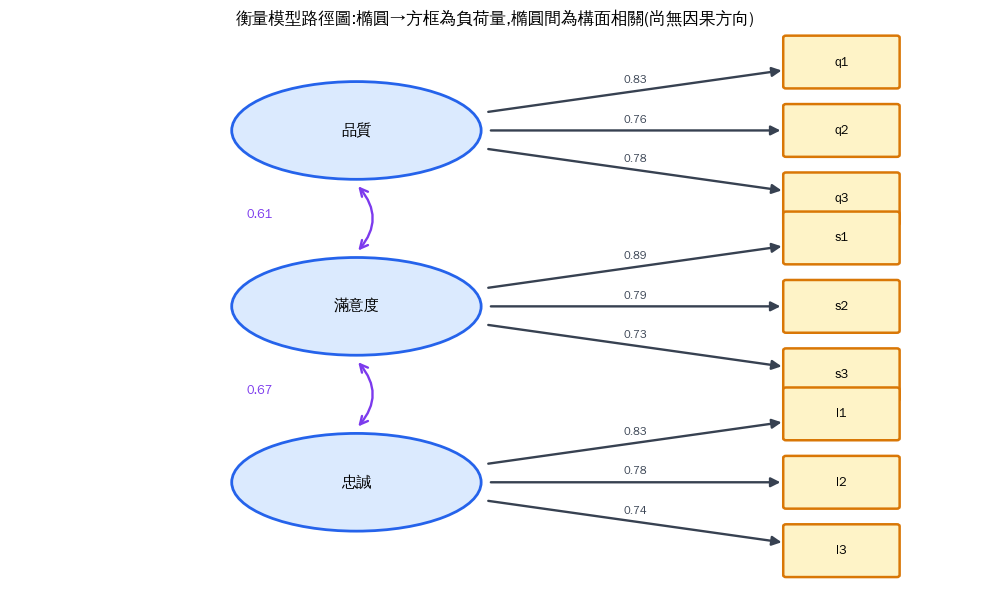

In [8]:
# 把衡量模型畫成路徑圖(含標準化負荷量)
def gl(ind_name, factor):
    r=ins[(ins["lval"]==ind_name)&(ins["rval"]==factor)&(ins["op"]=="~")]
    return float(r["Est. Std"].iloc[0])
fig,ax=plt.subplots(figsize=(10,6))
cfg=[("Quality","品質",4.6,["q1","q2","q3"]),
     ("Satisfaction","滿意度",2.8,["s1","s2","s3"]),
     ("Loyalty","忠誠",1.0,["l1","l2","l3"])]
for fac,lab,cy,items in cfg:
    node(ax,(5,cy),lab,w=1.8,h=1.0,fs=11)
    for k,it in enumerate(items):
        iy=cy+0.7-0.7*k
        node(ax,(8.5,iy),it,kind="obs",w=0.8,h=0.5,fs=9)
        arrow(ax,(5,cy),(8.5,iy),r1=0.95,r2=0.42,label=f"{gl(it,fac):.2f}",dy=0.08,fs=8)
# 構面間相關(雙箭頭)
arrow(ax,(5,4.6),(5,2.8),two_head=True,curved=-0.45,color="#7c3aed",
      label=f"{fcorr('Quality','Satisfaction'):.2f}",r1=0.55,r2=0.55,dx=-0.7,dy=0,fs=9)
arrow(ax,(5,2.8),(5,1.0),two_head=True,curved=-0.45,color="#7c3aed",
      label=f"{fcorr('Satisfaction','Loyalty'):.2f}",r1=0.55,r2=0.55,dx=-0.7,dy=0,fs=9)
ax.set_xlim(2.5,9.5); ax.set_ylim(0,5.6); ax.axis("off")
ax.set_title("衡量模型路徑圖:橢圓→方框為負荷量,橢圓間為構面相關(尚無因果方向)",fontsize=12)
plt.tight_layout(); plt.show()

---
## 第 4 章　結果如何書寫與判讀

把上面四張表整合,就是論文中「衡量模型」段落的標準寫法。以本案例為例:

> 「驗證性因素分析結果顯示,所有題目的標準化因素負荷量介於 0.72–0.89,均達 0.7 以上且顯著 (p < .001)。三個構面的組合信度 (CR) 介於 0.83–0.85,皆高於 0.70,顯示**信度良好**;平均變異萃取量 (AVE) 介於 0.61–0.65,皆高於 0.50,**收斂效度成立**。Fornell-Larcker 檢定顯示各構面 √AVE 均大於其與其他構面之相關,**區別效度獲得支持**。整體模型適配良好 (CFI、TLI > 0.95,RMSEA < 0.06,SRMR < 0.08)。」

### 一張判準速查表

| 指標 | 看什麼 | 達標門檻 |
|---|---|---|
| 因素負荷量 | 題目反映構面的強度 | ≥ 0.70 且顯著 |
| CR | 構面信度 | ≥ 0.70 |
| AVE | 收斂效度 | ≥ 0.50 |
| Fornell-Larcker | 區別效度 | √AVE > 構面間相關 |
| CFI / TLI | 整體適配 | > 0.95 |
| RMSEA / SRMR | 整體適配 | < 0.06 / < 0.08 |

---
## 第 5 章　如果不達標,怎麼辦?

衡量模型常常**第一次跑不會全過**,這是正常的。常見補救:

- **某題負荷量太低(< 0.5)**:該題沒量到構面,考慮**刪題**(但別刪到一個構面剩不到 3 題)。
- **AVE < 0.5 但 CR 夠**:收斂效度不足,通常也是靠刪掉低負荷題改善。
- **區別效度不過(兩構面相關過高,如 > 0.85)**:兩個構面可能根本是同一個,考慮**合併**,或檢查題目是否語意重疊。
- **適配度差**:看**修正指標 (Modification Indices, MI)**,它會提示「哪兩個誤差項若允許相關,卡方會降最多」。但**修正必須有理論依據**,不能為了好看亂改(那叫資料導向的過度配適)。

> 原則:**所有修正都要說得出道理**,並誠實報告改了什麼、為什麼改。

---
## 第 6 章　小結

你已經走完衡量模型的完整歷程:

1. **界定 → 估計**:用 $x=\Lambda\xi+\delta$、$\Sigma=\Lambda\Phi\Lambda'+\Theta$ 把構面和題目連起來。
2. **信度 (CR) → 收斂效度 (AVE) → 區別效度 (Fornell-Larcker) → 適配度**:四關都過,代表「**題目確實量到了構面**」。

本案例四關全過 ✅,測量品質可靠。**現在,也只有現在**,我們才有資格去問下一個問題:**這些構面之間,誰影響誰?**

➡️ 請接 **文件③:結構模型**,進入第二張拼圖。